### Importing Python modules (or libraries)

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

### Understand the data

In [4]:
# Load the dataset

df=pd.read_csv('car_prediction_data.csv')

In [6]:
# Number of rows and columns
df.shape

# Conclusion: 
# This data set have a 301 Rows and 9 Columns

(301, 9)

In [8]:
# Basic info

df.info()

# conclusion:

# we have 2 columns of float data type
# we have 3 columns of int data type
# we have 4 columns of object data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [10]:
# peak into the dataset

df.head()

# Conclusion
# Data looks clean with expected values

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [12]:
# check the null values

df.isnull().sum()

# Conclusion
# there are no null values in the dataset

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [14]:
# check Duplicate values

df.duplicated().sum()

# Conclusion:
# it seems there are 2 duplicate rows

2

In [16]:
# Drop duplicates

# since there are only 2 duplicate which are consider less compared to the size of the dataset we can drop them
df.drop_duplicates(inplace=True)

In [18]:
# creating car age column

df['Car_Age'] = 2025 - df['Year']
df.drop('Year',axis=1,inplace=True)

In [20]:
# Descriptive Statistics

df.describe()

# Conclusion:

# Selling_Price : avg-4.5, range - o.1
# to 35 (in lakhs), varying price
# Present_Price : avg - 7.5, range- 0.32 to 92(in lakhs), varing price
# Kms_Driven : avg- 36926, range- 500 to 500000
# Owners : have a range of 0 to 3 , 75% cars are of first hand
# Car_Age : avg - 11 years, range- 2 to 22 years old

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,4.589632,7.541037,36916.752508,0.043478,11.384615
std,4.984240,8.567887,39015.170352,0.248720,2.896868
min,0.100000,0.320000,500.000000,0.000000,7.000000
25%,0.850000,1.200000,15000.000000,0.000000,9.000000
50%,3.510000,6.100000,32000.000000,0.000000,11.000000
75%,6.000000,9.840000,48883.500000,0.000000,13.000000
max,35.000000,92.600000,500000.000000,3.000000,22.000000


#### Conclusion on the dataset:


### Exploratory Data Analysis

### Univariate analysis:


#### Car_Age Column:

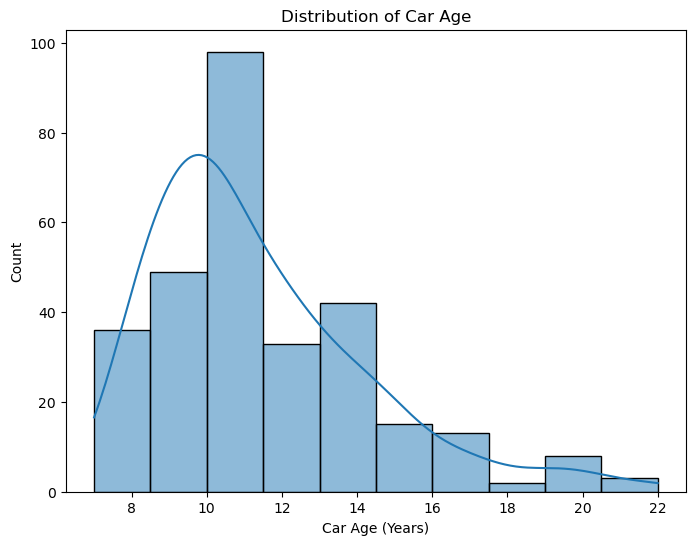

In [17]:
# Histogram for Year column:

plt.figure(figsize=(8,6))
sns.histplot(df['Car_Age'], bins=10, kde=True)
plt.title('Distribution of Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Count')
plt.show()


# Conlusion:

# most car are of age less than 11 years
# the distribution seems like it is right skewed 

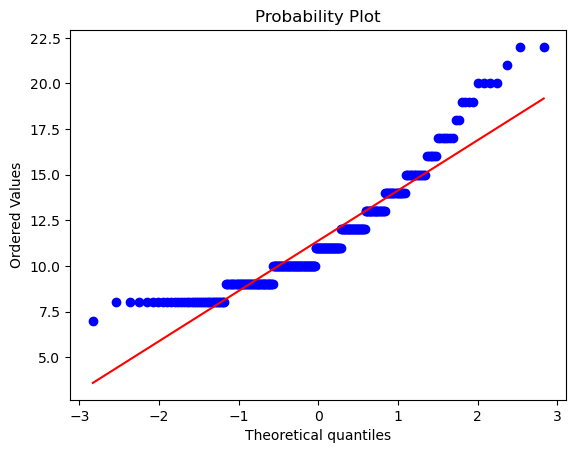

In [18]:
# QQ Plot of the Car_Age column

stats.probplot(df['Car_Age'],dist='norm', plot =plt)
plt.show()

# Conclusion:
# the distribuiton may not in Guassian Distribution
# we can't say for sure since the datapoits are very less

In [19]:
# AD test on Car_Age

data= df['Car_Age']

stat_val,crit_values,sign_values=stats.anderson(data,dist='norm')

for i in crit_values:
    if stat_val>i:
        print('H0 is reject : which means the column may not be in Guassian Distribution')
        break
else:
    print('H0 is accepted : which means the coumn may be in Guassian Distribution')

# Conlcuion:
# This column may not be in Guassina distribution

H0 is reject : which means the column may not be in Guassian Distribution


<Axes: ylabel='Car_Age'>

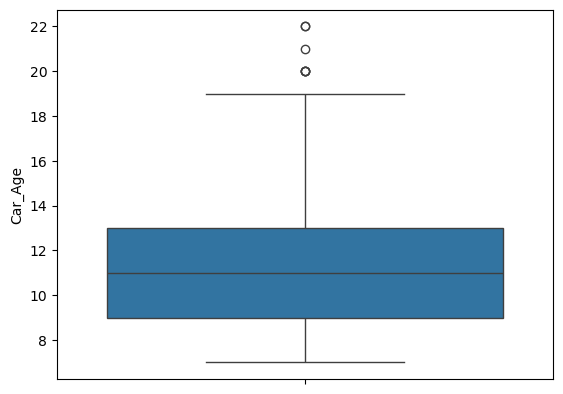

In [20]:
# Box Plot on Car_Age Column

sns.boxplot(df['Car_Age'])

# there are outliers present in the Car_age Column

#### Conclusion on Car_Age Column:

#### Selling_Price Column

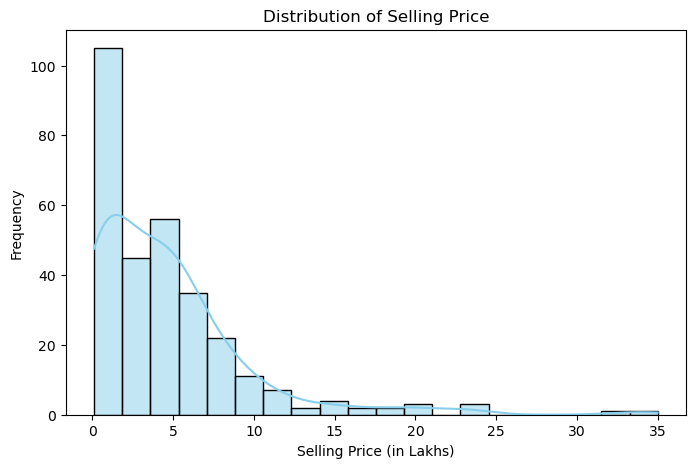

In [23]:
# Histogram for Selling_Price Column:

plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')
plt.show()

# Conlcusion:
# A majority of cars are sold for less than ₹5 lakhs, as observed in the distribution plot.
# The distribuion seem like right skewed

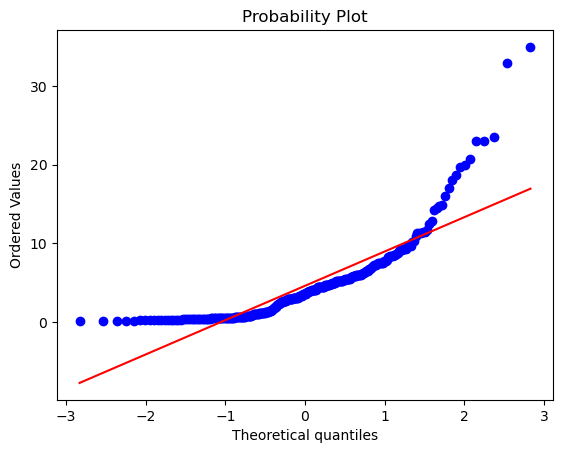

In [24]:
# QQ-Plot for Selling_Price Column

stats.probplot(df['Selling_Price'],dist='norm',plot=plt)
plt.show()

# Conclusion:
# The column may not be in Guassin Distribution

In [25]:
# AD Test


stat_val,crit_values,sign_values=stats.anderson(df['Selling_Price'],dist='norm')

for i in crit_values:
    if stat_val>i:
        print('H0 is reject : which means the column may not be in Guassian Distribution')
        break
else:
    print('H0 is accepted : which means the coumn may be in Guassian Distribution')

# Conclusion:
# This column may not be in Guassian Distribution.


H0 is reject : which means the column may not be in Guassian Distribution


<Axes: ylabel='Selling_Price'>

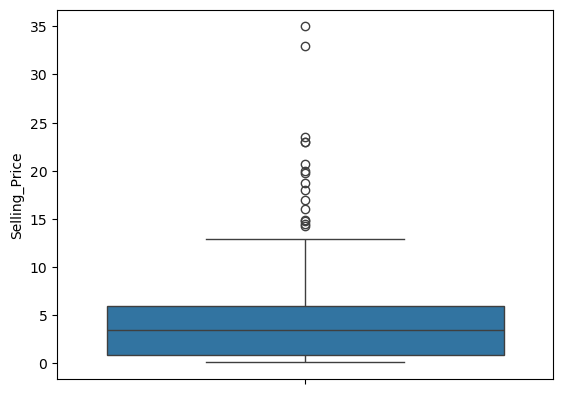

In [26]:
#  BOX Plot

sns.boxplot(df['Selling_Price'])

# Conclusion
# There are more number of outlier present in the column
# 50% of cars selling price is in 0 to 5 lakhs

#### Conclusion on Selling_Price Column:

#### Present_Price Column:

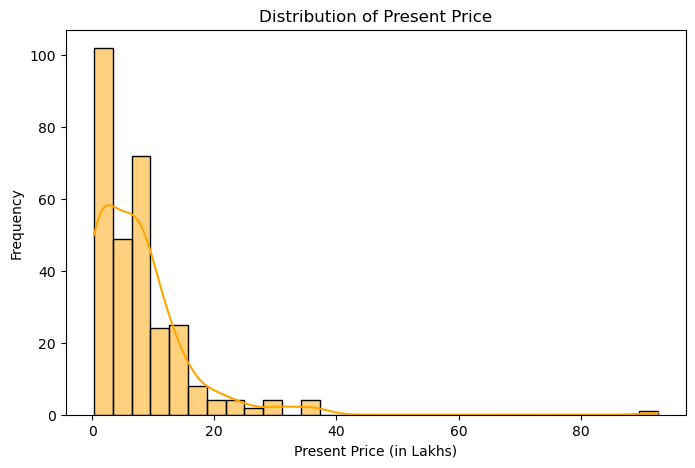

In [39]:
# Histogram for Present_Price Column


plt.figure(figsize=(8, 5))
sns.histplot(df['Present_Price'], bins=30, kde=True, color='orange')
plt.title('Distribution of Present Price')
plt.xlabel('Present Price (in Lakhs)')
plt.ylabel('Frequency')
plt.show()

# Conclusion:
# Most cars present price is less than 20 lakhs 
# new cars have more price than the old cars of same brand.

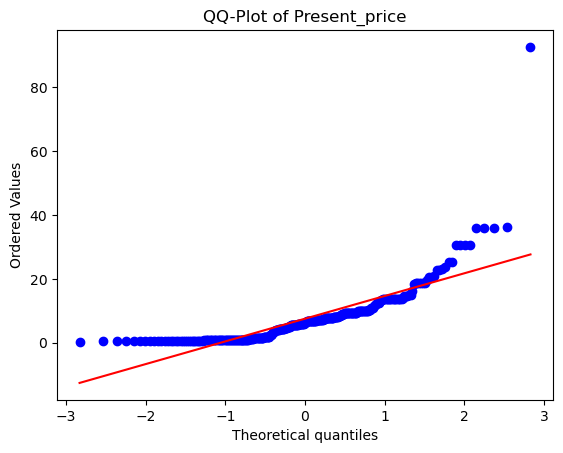

In [40]:
# QQ-Plot

stats.probplot(df['Present_Price'], dist='norm', plot= plt)
plt.title('QQ-Plot of Present_price')
plt.show()

# Conclusion:
# This column may not be in Gussian Distribution.

In [41]:
# AD Test

stat_val,crit_values,sign_values=stats.anderson(df['Present_Price'],dist='norm')

for i in crit_values:
    if stat_val>i:
        print('H0 is reject : which means the column may not be in Guassian Distribution')
        break
else:
    print('H0 is accepted : which means the coumn may be in Guassian Distribution')

# Conclusion:
# This column may not be in Guassian Distribution.

H0 is reject : which means the column may not be in Guassian Distribution


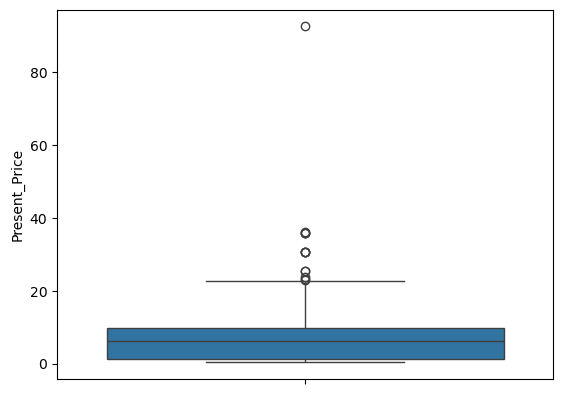

In [42]:
# Box Plot

sns.boxplot(df['Present_Price'])
plt.show()

# Conclusion:
#  There are outliers present in the Present_price column
# 50% if the Cars present price is 1 t0 16 lakhs

#### Conclusion on Present_Price Column:

#### Kms_Driven Column

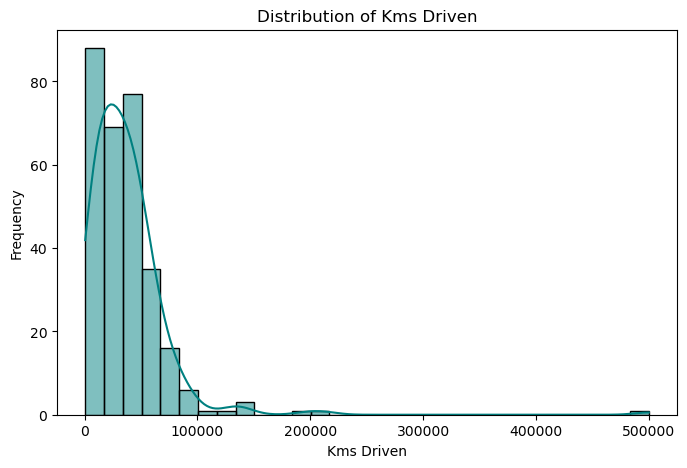

In [45]:
# Histogram for Kms_Driven

plt.figure(figsize=(8, 5))
sns.histplot(df['Kms_Driven'], bins=30, kde=True, color='teal')
plt.title('Distribution of Kms Driven')
plt.xlabel('Kms Driven')
plt.ylabel('Frequency')
plt.show()

# Conlusion:
# Most of the cars are dirven less than 50,000 kms 

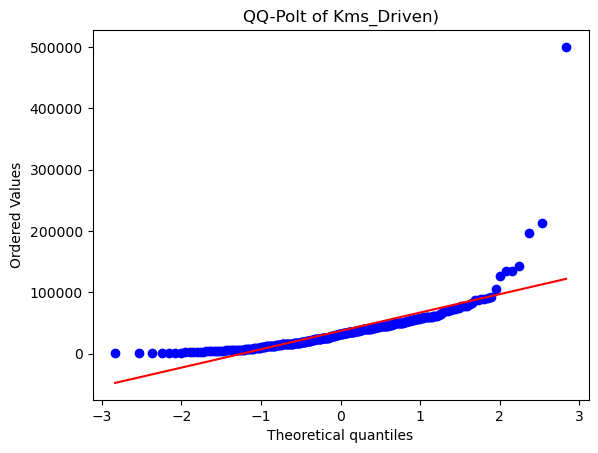

In [46]:
# QQ-Plot

stats.probplot(df['Kms_Driven'], dist='norm', plot=plt)
plt.title('QQ-Polt of Kms_Driven)')
plt.show()

# Conclusion:
# This column may not be in Guassian Distribution

In [47]:
# AD Test

stat_val,crit_values,sign_values=stats.anderson(df['Selling_Price'],dist='norm')

for i in crit_values:
    if stat_val>i:
        print('H0 is reject : which means the column may not be in Guassian Distribution')
        break
else:
    print('H0 is accepted : which means the coumn may be in Guassian Distribution')

# Conclusion:
# This column may not be in Guassian Distribution.

H0 is reject : which means the column may not be in Guassian Distribution


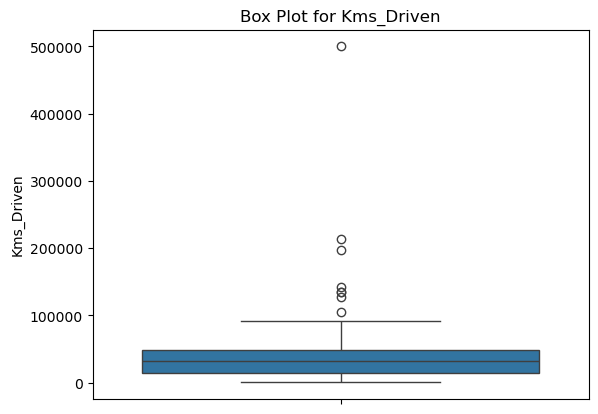

In [48]:
# Box Plot

sns.boxplot(df['Kms_Driven'])
plt.title('Box Plot for Kms_Driven')
plt.show()

# Conclusion:
# There are outliers present in the column
# 50% of cars are driven in between 15,000 km to 50,000 km

#### Conclusion on Kms_Driven

#### Owner Column:

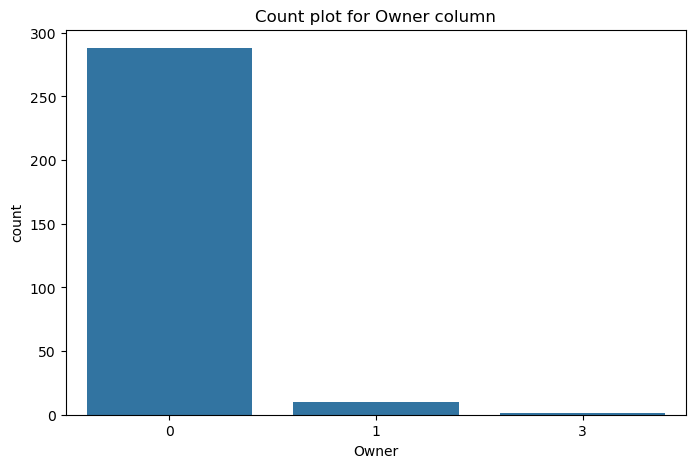

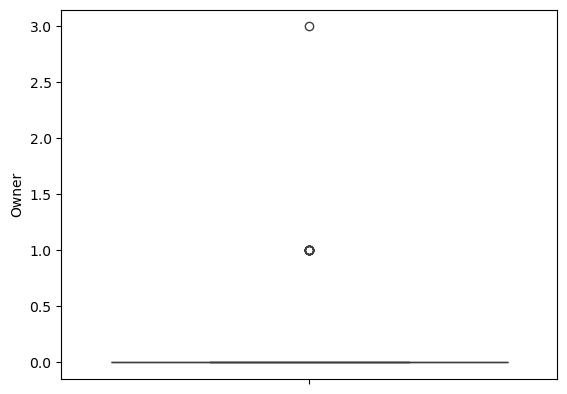

In [51]:
# Count Plot for Owner Column

plt.figure(figsize=(8,5))
sns.countplot(x='Owner',data=df)
plt.title('Count plot for Owner column')
plt.show()

sns.boxplot(df['Owner'])
plt.show()

#### Conclusion on Owner column:

#### Fuel_Type Column:

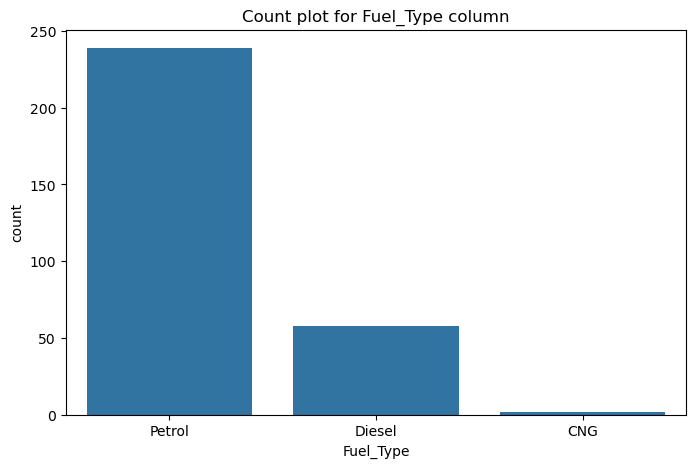

In [54]:
# Count Plot for Fuel_Type Column

plt.figure(figsize=(8,5))
sns.countplot(x='Fuel_Type',data=df)
plt.title('Count plot for Fuel_Type column')
plt.show()

#### Conclusion on Fuel_Type column

#### Seller_Type Column:

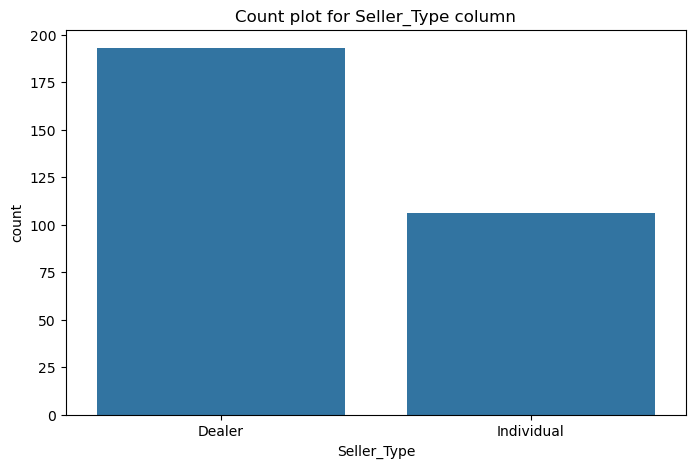

In [57]:
# Count Plot for Seller_Type Column

plt.figure(figsize=(8,5))
sns.countplot(x='Seller_Type',data=df)
plt.title('Count plot for Seller_Type column')
plt.show()

#### Conclusion on Seller_Type column:

#### Transmission Column:

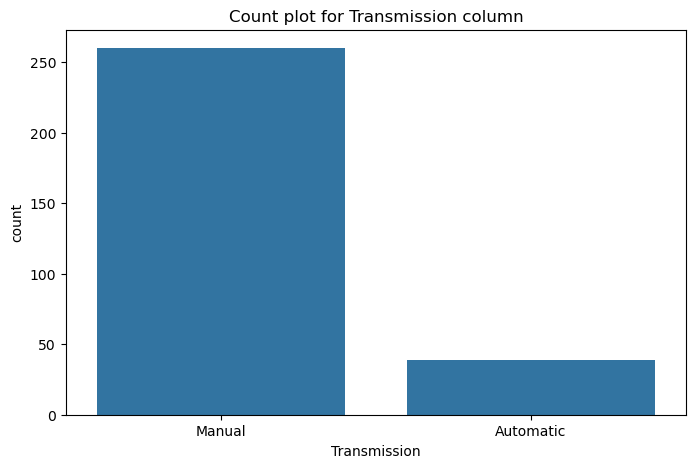

In [60]:
# Count Plot for Transmission Column

plt.figure(figsize=(8,5))
sns.countplot(x='Transmission',data=df)
plt.title('Count plot for Transmission column')
plt.show()

#### Conclusion on Transmission column:

### Conclusion on Univariate analysis:

### Handling outliers:

In [175]:
def Outliers(df):
    df_copied=df.copy()
    for column in df_copied.columns:
        if df[column].dtype == 'int64' or df[column].dtype=='float64':
            q3=np.percentile(df_copied[column],75) # df['Values'].quantile(0.25)
            q1=np.percentile(df_copied[column],25) # df['Values'].quantile(0.75)
            IQR=q3-q1
            lb= q1-(1.5*IQR)
            ub= q3+(1.5*IQR)
            df_copied[column] = df_copied[column].clip(lower=lb, upper=ub)
    df_copied['Owner']=df['Owner']
    return df_copied
df=Outliers(df)
 

### Encoding

In [178]:
from sklearn.preprocessing import LabelEncoder

def Encoding(df):
    df_copied = df.copy()
    
    for column in df_copied.columns:
        if df_copied[column].dtype == 'object':
            le = LabelEncoder()
            col_name = column + '_Encoded'
            df_copied[col_name] = le.fit_transform(df_copied[column])
    df_copied.drop('Car_Name_Encoded',axis=1,inplace=True)
    return df_copied
             
df=Encoding(df)

In [180]:
df

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Fuel_Type_Encoded,Seller_Type_Encoded,Transmission_Encoded
0,ritz,3.35,5.59,27000.0,Petrol,Dealer,Manual,0,11,2,0,1
1,sx4,4.75,9.54,43000.0,Diesel,Dealer,Manual,0,12,1,0,1
2,ciaz,7.25,9.85,6900.0,Petrol,Dealer,Manual,0,8,2,0,1
3,wagon r,2.85,4.15,5200.0,Petrol,Dealer,Manual,0,14,2,0,1
4,swift,4.60,6.87,42450.0,Diesel,Dealer,Manual,0,11,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988.0,Diesel,Dealer,Manual,0,9,1,0,1
297,brio,4.00,5.90,60000.0,Petrol,Dealer,Manual,0,10,2,0,1
298,city,3.35,11.00,87934.0,Petrol,Dealer,Manual,0,16,2,0,1
299,city,11.50,12.50,9000.0,Diesel,Dealer,Manual,0,8,1,0,1


### Bivariate Analysis

#### HeatMap

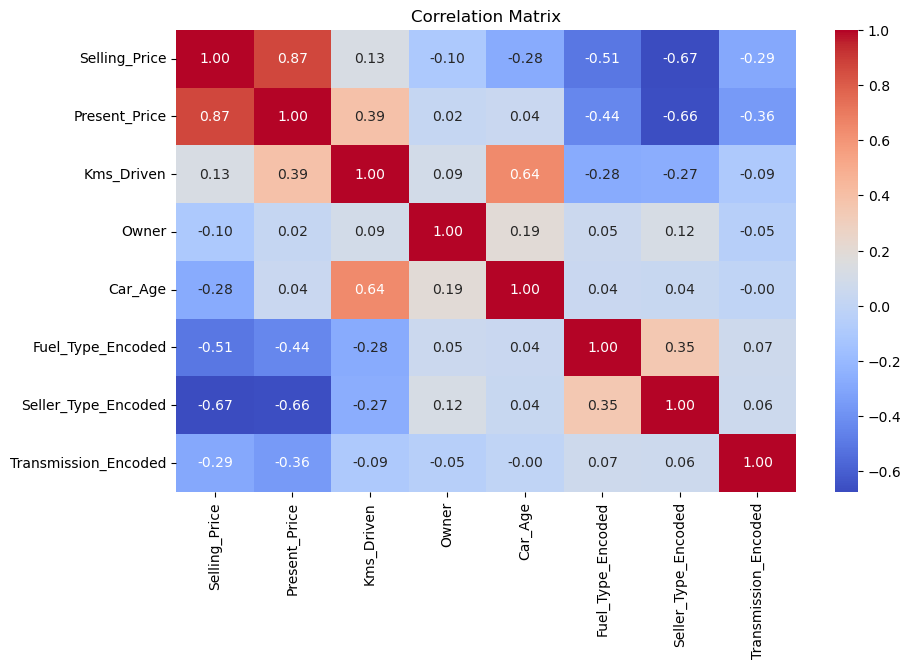

In [182]:
# Only numerical columns
numerical_cols = df.select_dtypes(include='number')


# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Conclusion


# present_Price:0.88
    # shows very positive correaltion

# Kms_Drive: 0.13
    # show weak correaltion

# Car_Age: -0.28
    # weak negative relationship

# Owner : -0.1
    # show weak negative relationship

# Fuel_type: -0.51
    # shoW negative relationship

# Seller_Type : -0.67
    # Show positive relationship

# Transmission : -029
    # show weak negative relationship

#### Car_Age(Numerical) vs Selling_Price (Numerical Target)

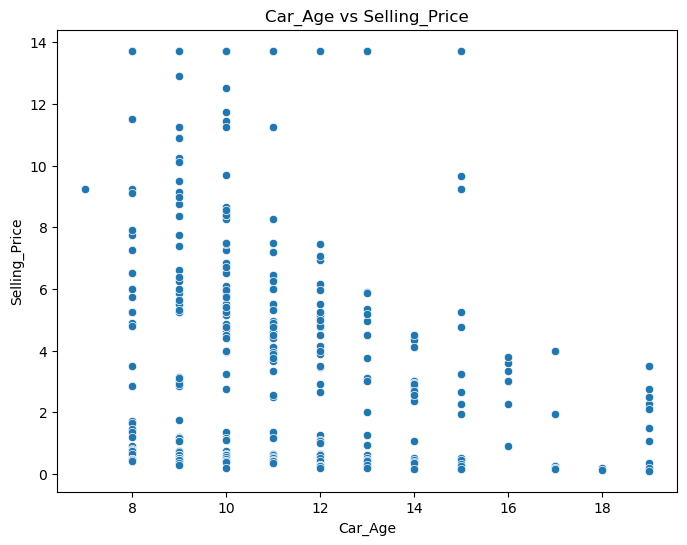

In [72]:
# Scatter Plot 

plt. figure(figsize=(8,6))
sns.scatterplot(data=df,y='Selling_Price',x='Car_Age')
plt.title('Car_Age vs Selling_Price')
plt.show()

#### Conclusion on Car_Age vs Selling_Price

#### Present_price(Numerical) vs Selling_Price (Numerical Target)

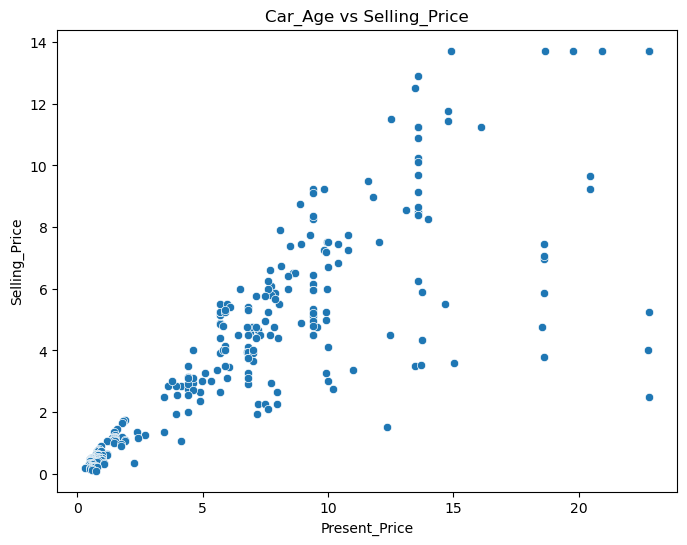

In [75]:
# Scatter plot

plt. figure(figsize=(8,6))
sns.scatterplot(data=df,x='Present_Price',y='Selling_Price')
plt.title('Car_Age vs Selling_Price')
plt.show()


#### Conclusion on Present_Price vs Selling_Price

#### Kms_Driven(Numerical) vs Selling_Price (Numerical Target)

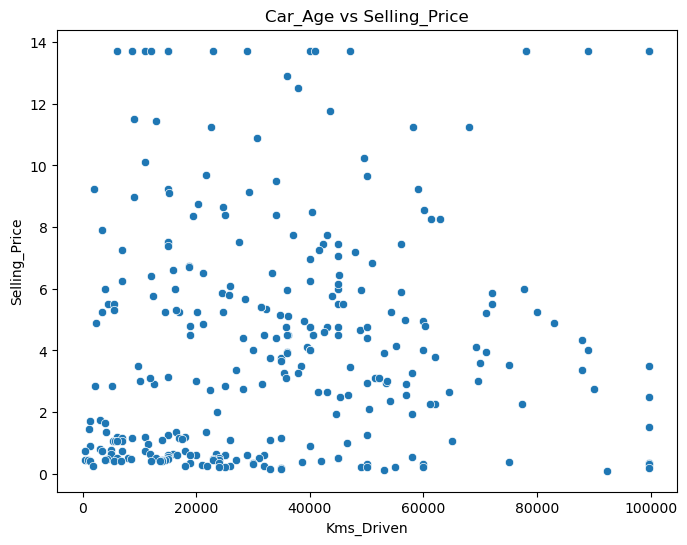

In [83]:
# Scatter plot

plt. figure(figsize=(8,6))
sns.scatterplot(data=df,x='Kms_Driven',y='Selling_Price')
plt.title('Car_Age vs Selling_Price')
plt.show()

#### Conclusion on Kms_Driven vs Selling_Price

#### Owner(Numerical) vs Selling_Price (Numerical Target)

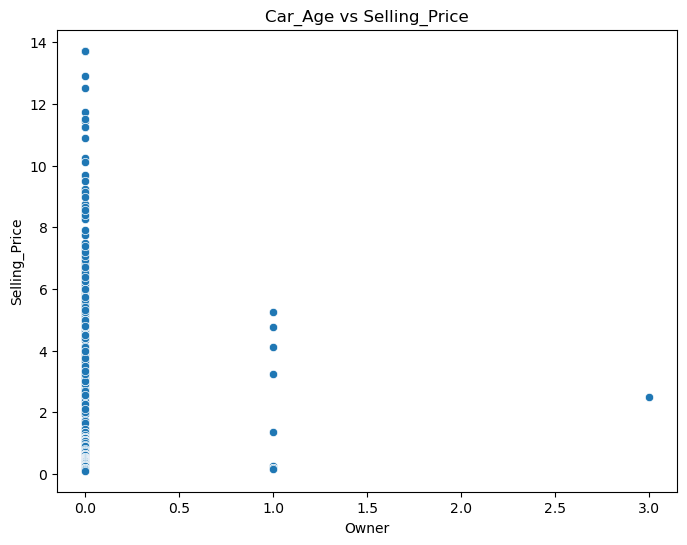

In [86]:
# Scatter plot

plt. figure(figsize=(8,6))
sns.scatterplot(data=df,x='Owner',y='Selling_Price')
plt.title('Car_Age vs Selling_Price')
plt.show()

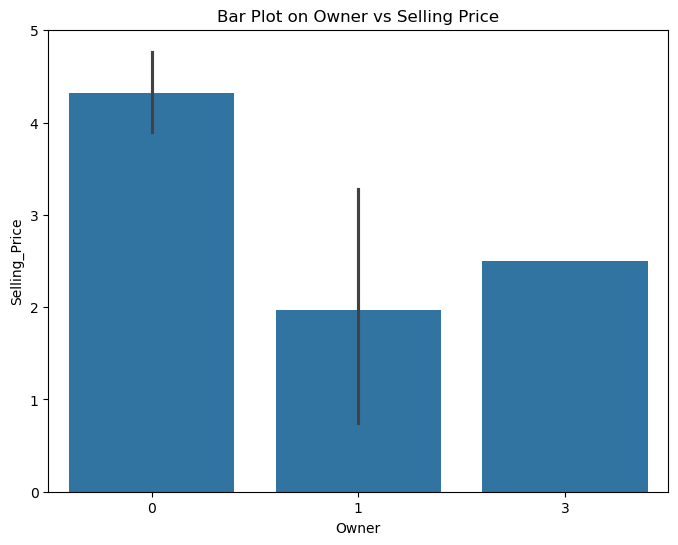

In [89]:
# Bar Plot

plt.figure(figsize=(8,6))
sns.barplot(data=df,x='Owner',y='Selling_Price')
plt.title('Bar Plot on Owner vs Selling Price')
plt.show()

#### Conclusion on Owner vs Selling_Price

####  Fuel_Type(Categorical) vs Selling _Price(Numerical Target)

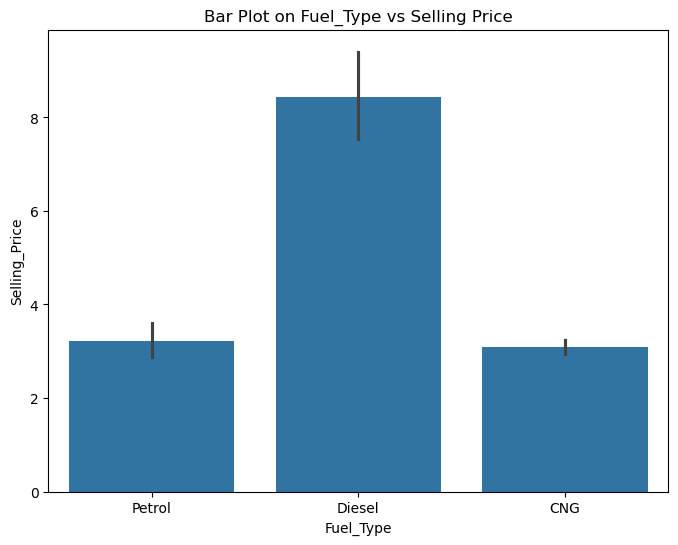

In [91]:
# Bar Plot

plt.figure(figsize=(8,6))
sns.barplot(data=df,x='Fuel_Type',y='Selling_Price')
plt.title('Bar Plot on Fuel_Type vs Selling Price')
plt.show()

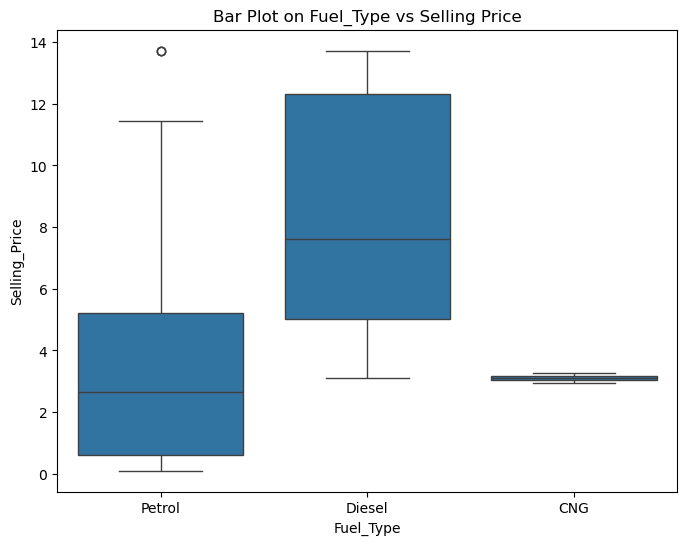

In [108]:
# Box Plot

plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Fuel_Type',y='Selling_Price')
plt.title('Bar Plot on Fuel_Type vs Selling Price')
plt.show()

#### Conclusion on Fuel_Type vs Selling_Price

#### Seller_type(Categorical) vs Selling_Price(Numerical Target)

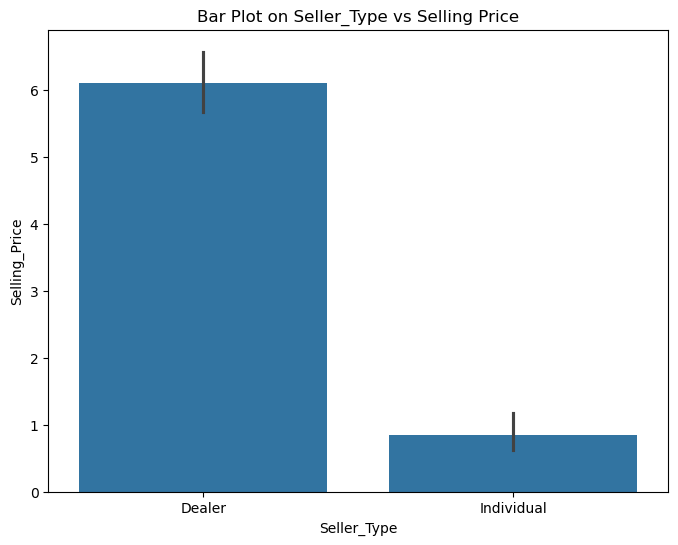

In [110]:
# Bar Plot

plt.figure(figsize=(8,6))
sns.barplot(data=df,x='Seller_Type',y='Selling_Price')
plt.title('Bar Plot on Seller_Type vs Selling Price')
plt.show()

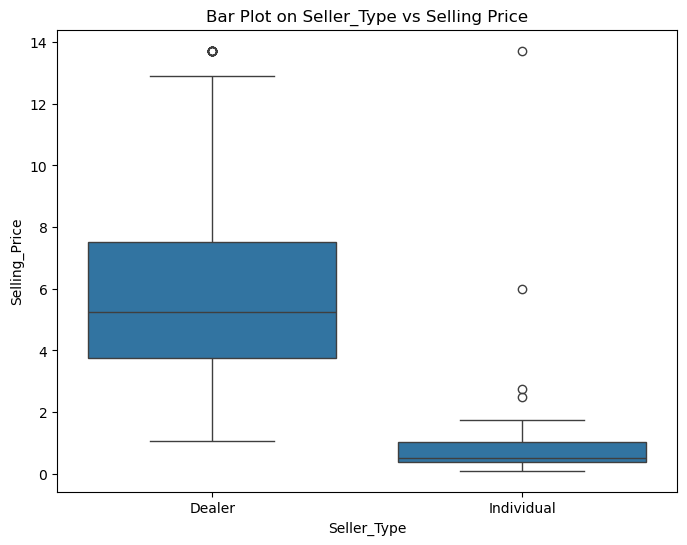

In [112]:
# Box Plot

plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Seller_Type',y='Selling_Price')
plt.title('Bar Plot on Seller_Type vs Selling Price')
plt.show()

#### Conclusion on Seller_Type vs Selling_Price

#### Transmission(Categorical) vs Selling _Price(Numerical Target)

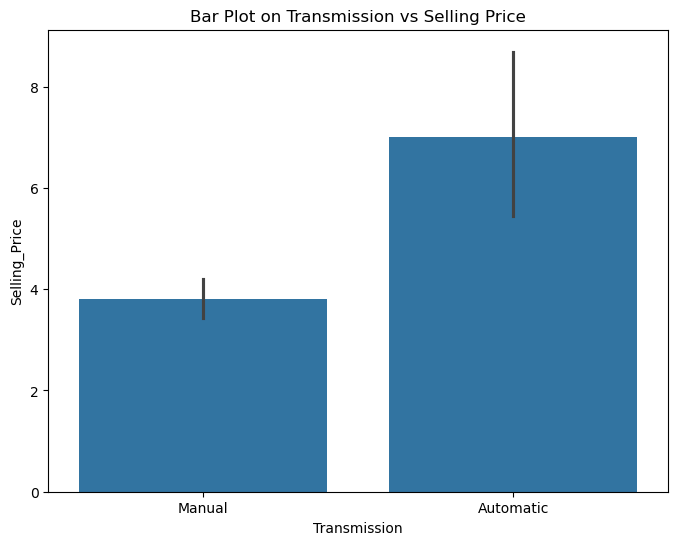

In [116]:
# Bar Plot

plt.figure(figsize=(8,6))
sns.barplot(data=df,x='Transmission',y='Selling_Price')
plt.title('Bar Plot on Transmission vs Selling Price')
plt.show()

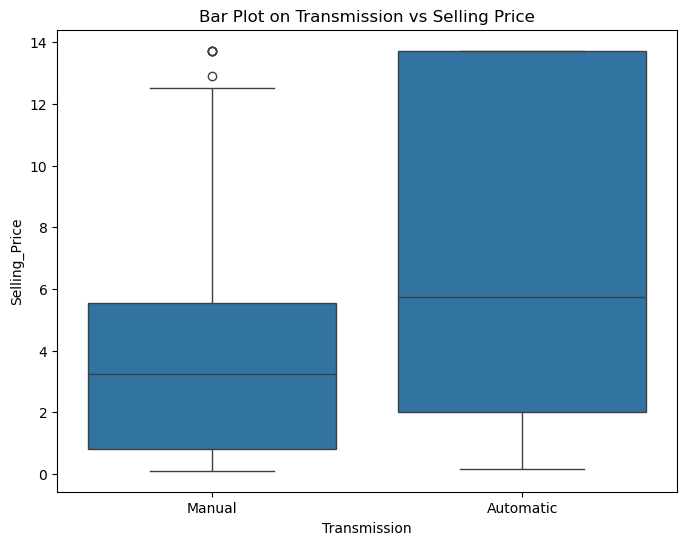

In [118]:
# Box Plot

plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Transmission',y='Selling_Price')
plt.title('Bar Plot on Transmission vs Selling Price')
plt.show()

#### Conclusion on Transmission vs Selling_Price

### Multivariate Analysis

#### Heatmap: 

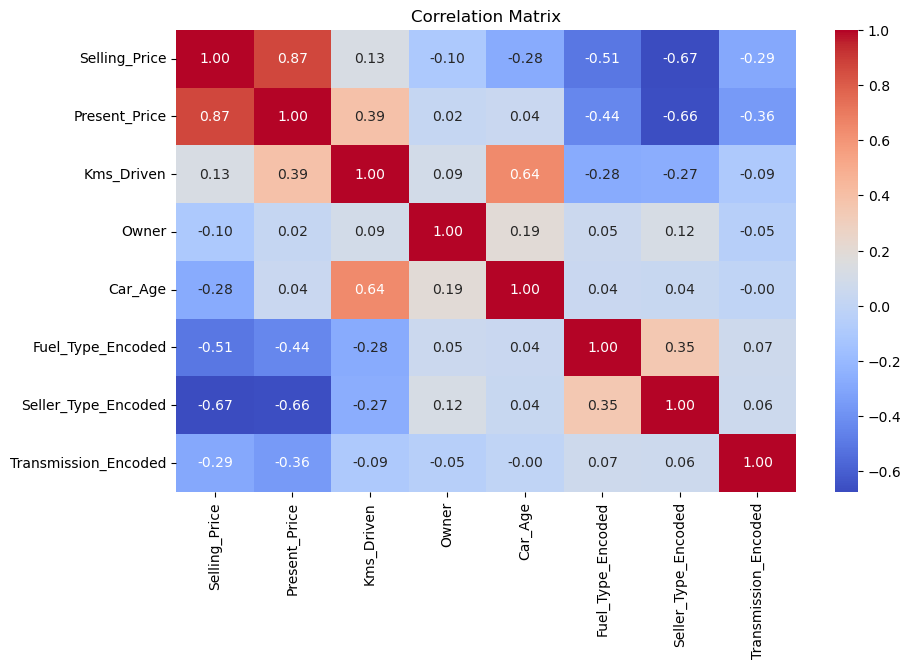

In [197]:
# Only numerical columns
numerical_cols = df.select_dtypes(include='number')


# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Cnclusion:

#  Present_Price vs Fuel_Type : -0.44
    # There is a moderate negative relation between these two columns

#  Present_Price vs Seller_Type: 0.66
    # There is  Strong negative realtion between these two columns 

# Car_Age vs Kms_Driven: 0.64
    # Strong positive relation

# Fuel_Type vs Seller_Type : 0.35
    # Weak positive relation

In [45]:
# Create a new column called 'Price_Category'
df['Price_Category'] = pd.cut(df['Selling_Price'],
                               bins=[0, 3, 6, 20],
                               labels=['Low', 'Medium', 'High'])


#### Present_Price(Numerical) and Fuel_Type(Categorical) and Selling_Price(numerical):

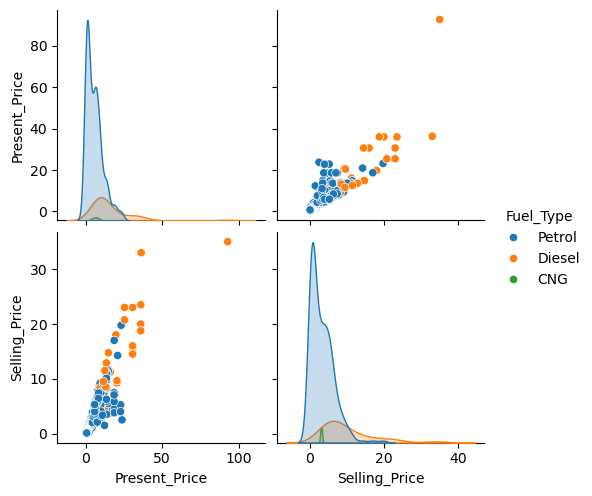

In [74]:
# Pair Plot

sns.pairplot(df[['Present_Price','Selling_Price','Fuel_Type']],hue='Fuel_Type')
plt.show()

#### Conclusion:

#### Car_Age(Numerical) and Kms_Driven(NUmerical) and Price_Category(Categorical):

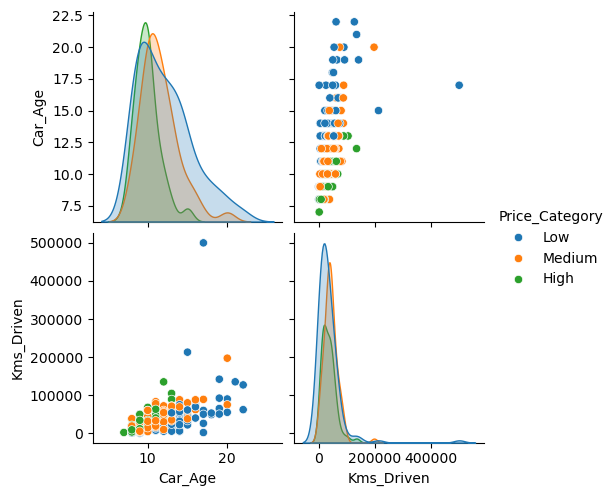

In [77]:
sns.pairplot(df[['Car_Age','Kms_Driven','Price_Category']],hue='Price_Category')
plt.show()

#### Conclusion

### Over all Conlusion on Multivariate analysis